In [1]:
import tensorflow as tf

In [2]:
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt

In [3]:
ds =tfds.load('fashion_mnist',split='train')

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/fashion_mnist/incomplete.MAA5PP_3.0.1/fashion_mnist-train.tfrecord*...:   …

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/fashion_mnist/incomplete.MAA5PP_3.0.1/fashion_mnist-test.tfrecord*...:   0…

Dataset fashion_mnist downloaded and prepared to /root/tensorflow_datasets/fashion_mnist/3.0.1. Subsequent calls will reuse this data.


## Viz data and build dataset

In [4]:
import numpy as np

In [5]:
dataiterator = ds.as_numpy_iterator()

In [6]:
# getting data out of pipeline
dataiterator.next()

{'image': array([[[  0],
         [  0],
         [  0],
         [  0],
         [  0],
         [  0],
         [  0],
         [  0],
         [  0],
         [ 18],
         [ 77],
         [227],
         [227],
         [208],
         [210],
         [225],
         [216],
         [ 85],
         [ 32],
         [  0],
         [  0],
         [  0],
         [  0],
         [  0],
         [  0],
         [  0],
         [  0],
         [  0]],
 
        [[  0],
         [  0],
         [  0],
         [  0],
         [  0],
         [  0],
         [  0],
         [ 61],
         [100],
         [ 97],
         [ 80],
         [ 57],
         [117],
         [227],
         [238],
         [115],
         [ 49],
         [ 78],
         [106],
         [108],
         [ 71],
         [  0],
         [  0],
         [  0],
         [  0],
         [  0],
         [  0],
         [  0]],
 
        [[  0],
         [  0],
         [  0],
         [  0],
         [  0],
         

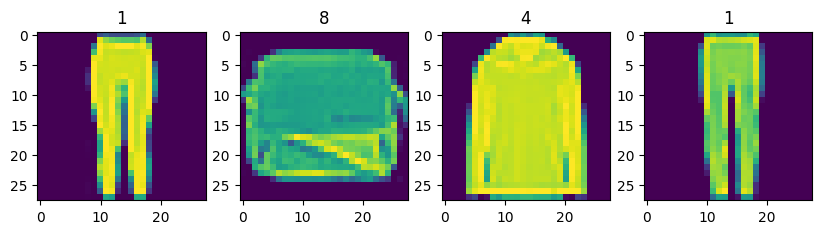

In [7]:
fig, ax = plt.subplots(ncols=4, figsize=(10,10))
for idx in range(4):
  sample =dataiterator.next()
  ax[idx].imshow(np.squeeze(sample['image']))
  ax[idx].title.set_text(sample['label'])


In [8]:
# scale and return images only
def scale_images(data):
  image =data['image']
  return image/255

In [9]:
# building data pipeline
ds =ds.map(scale_images)
ds =ds.cache()
ds =ds.shuffle(60000)
ds =ds.batch(128)
ds =ds.prefetch(64)

In [10]:
ds.as_numpy_iterator().next().shape

(128, 28, 28, 1)

## Build Neural Network

In [11]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, Dense, Flatten, Reshape, LeakyReLU, Dropout, UpSampling2D

#### Build Generator

In [12]:
def build_generator():
  model =Sequential()

  # takes in random values and reshape its to 7*7*128
  model.add(Dense(7*7*128, input_dim=128))
  model.add(LeakyReLU(alpha=0.2))
  model.add(Reshape((7,7,128)))

  #upsamplin block 1
  model.add(UpSampling2D())
  model.add(Conv2D(128,5, padding='same'))
  model.add(LeakyReLU(alpha=0.2))

  #upsampling block 2
  model.add(UpSampling2D())
  model.add(Conv2D(128,5,padding='same'))
  model.add(LeakyReLU(alpha=0.2))

  # Convolution block 1
  model.add(Conv2D(128,4,padding='same'))
  model.add(LeakyReLU(alpha=0.2))

  # Convolution block 2
  model.add(Conv2D(128,4,padding='same'))
  model.add(LeakyReLU(alpha=0.2))

  # conv layer to get to one channel
  model.add(Conv2D(1,4, padding='same', activation='sigmoid'))


  return model

In [13]:
generator =build_generator()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


In [14]:
generator.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 6272)           │       809,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 14, 14, 128)    │       409,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 128)    │       409,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 128)    │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 1)      │         2,049 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,155,137 (8.22 MB)

 Trainable params: 2,155,137 (8.22 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
img =generator.predict(np.random.randn(4,128,1))
img

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


array([[[[0.4910895 ],
         [0.4866116 ],
         [0.4864416 ],
         ...,
         [0.49964452],
         [0.49383068],
         [0.49631637]],

        [[0.48088422],
         [0.4773492 ],
         [0.47897243],
         ...,
         [0.48987696],
         [0.4891219 ],
         [0.49439117]],

        [[0.47606263],
         [0.4689259 ],
         [0.47455156],
         ...,
         [0.49528903],
         [0.49274442],
         [0.4953778 ]],

        ...,

        [[0.4773564 ],
         [0.47930247],
         [0.49034995],
         ...,
         [0.48710445],
         [0.492538  ],
         [0.499381  ]],

        [[0.4809269 ],
         [0.47988507],
         [0.48063064],
         ...,
         [0.4871276 ],
         [0.49407977],
         [0.49845958]],

        [[0.49084744],
         [0.49117416],
         [0.4916268 ],
         ...,
         [0.4910887 ],
         [0.49488777],
         [0.49556622]]],


       [[[0.49490955],
         [0.49950054],
         [0.50

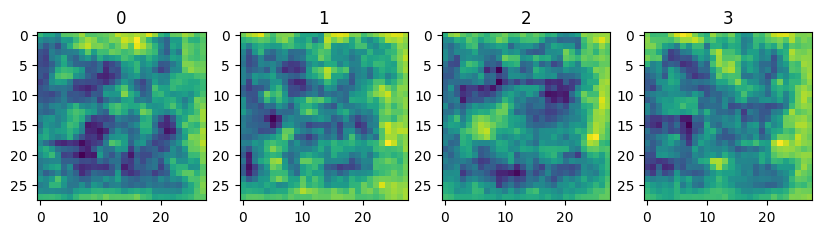

In [16]:
fig, ax = plt.subplots(ncols=4, figsize=(10,10))
for idx, img in enumerate(img):

  ax[idx].imshow(np.squeeze(img))
  ax[idx].title.set_text(idx)

## Build Discriminator

In [17]:
def build_discriminator():
  model=Sequential()

  #first Conv block
  model.add(Conv2D(32,5, input_shape= (28,28,1)))
  model.add(LeakyReLU(alpha=0.2))
  model.add(Dropout(0.4))

  #Second Conv block
  model.add(Conv2D(64,5))
  model.add(LeakyReLU(alpha=0.2))
  model.add(Dropout(0.4))

  #third Conv block
  model.add(Conv2D(128,5))
  model.add(LeakyReLU(alpha=0.2))
  model.add(Dropout(0.4))

  #fourht Conv block
  model.add(Conv2D(256,5))
  model.add(LeakyReLU(alpha=0.2))
  model.add(Dropout(0.4))

  # flatten layer
  model.add(Flatten())
  model.add(Dropout(0.4))
  model.add(Dense(1,activation='sigmoid'))

  return model

In [18]:
discriminator =build_discriminator()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [19]:
discriminator.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 24, 24, 32)     │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 20, 20, 64)     │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_6 (LeakyReLU)       │ (None, 20, 20, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 20, 20, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 128)    │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_7 (LeakyReLU)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 12, 12, 256)    │       819,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_8 (LeakyReLU)       │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │        36,865 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,113,345 (4.25 MB)

 Trainable params: 1,113,345 (4.25 MB)

 Non-trainable params: 0 (0.00 B)

In [40]:
img.shape

(28, 28, 1)

In [41]:
discriminator.predict(np.expand_dims(img, axis=0))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 651ms/step


array([[0.49376214]], dtype=float32)

## Custom training loop

In [20]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import BinaryCrossentropy

In [21]:
g_opt = Adam(learning_rate=0.0001)
d_opt = Adam(learning_rate=0.00001)
g_loss = BinaryCrossentropy()
d_loss = BinaryCrossentropy()

In [22]:
from tensorflow.keras.models import Model

In [23]:
class FashionGAN(Model):
  def __init__(self, generator, discriminator, *args,**kwargs):
    super(FashionGAN, self).__init__(*args,**kwargs)

    # create attributes for gen and disc
    self.generator =generator
    self.discriminator =discriminator

  def compile(self, g_opt,d_opt,g_loss,d_loss,*args,**kwargs):
    super().compile(*args,**kwargs)

    self.g_opt =g_opt
    self.d_opt =d_opt
    self.g_loss =g_loss
    self.d_loss =d_loss

  def train_step(self,batch):

    real_images =batch
    fake_images =self.generator(tf.random.normal((128,128,1)),training=False)

    #train a discriminator
    with tf.GradientTape() as d_tape:
      yhat_real = self.discriminator(real_images, training=True)
      yhat_fake =self.discriminator(fake_images,training=True)
      yhat_realfake =tf.concat([yhat_real,yhat_fake], axis=0)

      # create label for real and fake images
      y_realfake =tf.concat([tf.zeros_like(yhat_real),tf.ones_like(yhat_fake)], axis=0)

      # add some noise to the outputs
      noise_real =0.15*tf.random.uniform(tf.shape(yhat_real))
      noise_fake =-0.15*tf.random.uniform(tf.shape(yhat_fake))
      y_realfake = tf.concat([noise_real,noise_fake], axis=0)

      # calculate loss
      total_d_loss = self.d_loss(y_realfake,yhat_realfake)

    # apply backpropagation
    dgrad =d_tape.gradient(total_d_loss, self.discriminator.trainable_variables)
    self.d_opt.apply_gradients(zip(dgrad,self.discriminator.trainable_variables))

    with tf.GradientTape() as g_tape:
      # generate some new images
      gen_images =self.generator(tf.random.normal((128,128,1)),training=True)

      # create predicted labels
      predicted_labels =self.discriminator(gen_images, training=False)
      # calculate loss
      total_g_loss =self.g_loss(tf.zeros_like(predicted_labels), predicted_labels)

    # apply backpropagation
    ggrad =g_tape.gradient(total_g_loss,self.generator.trainable_variables)
    self.g_opt.apply_gradients(zip(ggrad,self.generator.trainable_variables))

    return{"d_loss": total_d_loss, "g_loss":total_g_loss}



In [24]:
fashgan = FashionGAN(generator,discriminator)

In [25]:
# compile the model
fashgan.compile(g_opt,d_opt,g_loss,d_loss)

In [26]:
# build the callback
import os
from tensorflow.keras.preprocessing.image import array_to_img
from tensorflow.keras.callbacks import Callback

In [28]:
class ModelMonitor(Callback):
  def __init__(self, num_img=3, latent_dim=128):
    self.num_img =num_img
    self.latent_dim =latent_dim

  def on_epoch_end(self,epoch, logs=None):
    random_latent_vectors =tf.random.uniform((self.num_img,self.latent_dim,1))
    generated_images =self.model.generator(random_latent_vectors)
    generated_images *=255
    generated_images.numpy()
    for i in range(self.num_img):
      img =array_to_img(generated_images[i])
      img.save(os.path.join('images',f'generated_img_{epoch}_{i}.png'))


In [31]:
# train
import os
if not os.path.exists('images'):
    os.makedirs('images')
hist =fashgan.fit(ds,epochs=100,callbacks=[ModelMonitor()])

Epoch 1/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 62s 131ms/step - d_loss: -0.5092 - g_loss: 1.7543e-09
Epoch 2/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 61s 131ms/step - d_loss: -0.5533 - g_loss: 3.9350e-09
Epoch 3/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 61s 131ms/step - d_loss: -0.5591 - g_loss: 1.1143e-09
Epoch 4/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 61s 131ms/step - d_loss: -0.5518 - g_loss: 2.1643e-09
Epoch 5/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 61s 131ms/step - d_loss: -0.6268 - g_loss: 5.8730e-10
Epoch 6/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 61s 131ms/step - d_loss: -0.5933 - g_loss: 1.1444e-09
Epoch 7/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 61s 131ms/step - d_loss: -0.5868 - g_loss: 1.4566e-09
Epoch 8/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 61s 131ms/step - d_loss: -0.5410 - g_loss: 6.6061e-10
Epoch 9/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 61s 131ms/step - d_loss: -0.5895 - g_loss: 4.8267e-10
Epoch 10/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 61s 131ms/step - d_loss: -0.6247 - g_loss: 9.6905e-10
Epoch 11/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 61s 131

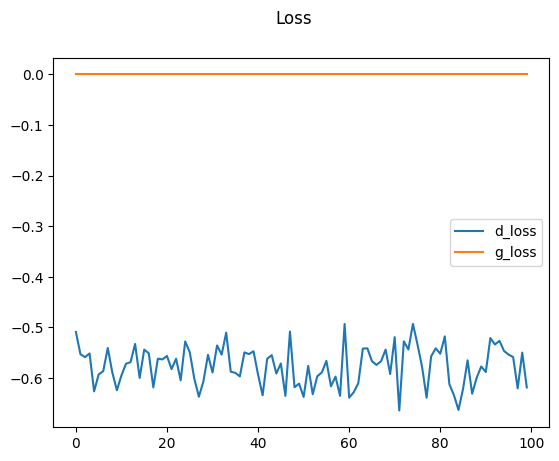

In [32]:
plt.suptitle('Loss')
plt.plot(hist.history['d_loss'], label='d_loss')
plt.plot(hist.history['g_loss'], label='g_loss')
plt.legend()
plt.show()

### Testing Generator

In [33]:
imgs = generator.predict(tf.random.normal((16,128,1)))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


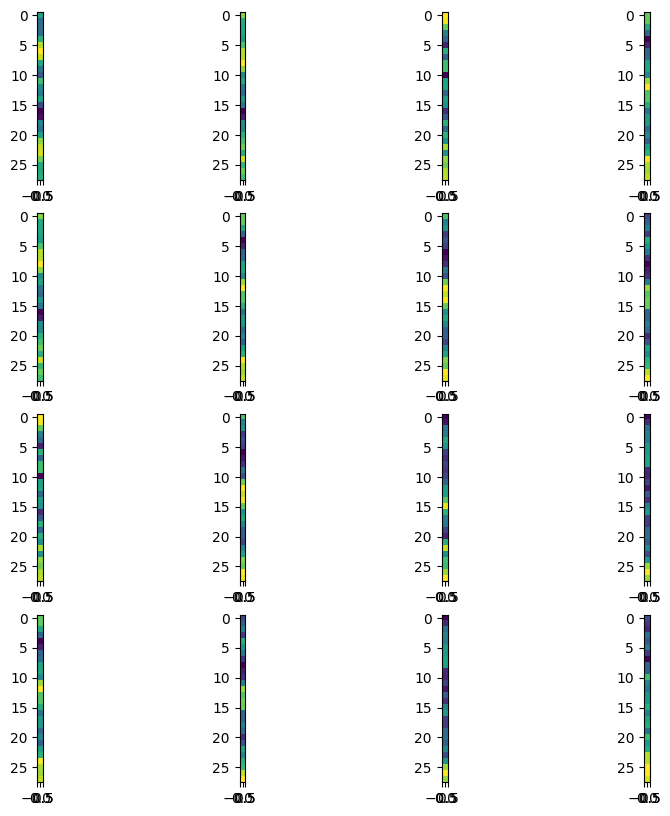

In [34]:
fig, ax =plt.subplots(ncols=4, nrows=4, figsize=(10,10))
for r in range(4):
  for c in range(4):
    ax[r][c].imshow(img[(r+1)*(c+1)-1])

##Saving the model

In [35]:
generator.save('generator_100.h5')
discriminator.save('discriminator_100.h5')
